# 🚁 Helipoint Detector — Experiment 2

---
### YOLOv8n · Original PUC-SP dataset · 100 epochs

**PUC-SP · Machine Learning and Computer Vision**

This is the **official second experiment** for the briefing's ablation requirement: same dataset, same model, same seed as exp1 — only `epochs` changes (60 → 100).

| | |
|---|---|
| Dataset | `pedros-workspace-1w4rz/my-first-project-kfo4l`, version 2 (same as exp1) |
| Model | YOLOv8n, **100 epochs**, imgsz=640, seed=42 |
| Outputs | trained weights (`.pt` + `.onnx`), metrics, exp1-vs-exp2 comparison |

> **Attribution:** The original dataset (images, annotations, SP neighborhoods) was created and curated by
> Pedro Vyctor Almeida. This notebook (exp2 — 100 epochs) was written and executed by Fabiana
> Campanari, using his public dataset as a base, for the briefing's ablation experiment.

> **Whose API key do I use?** **Yours.** This dataset is public on Roboflow Universe (CC BY 4.0,
> confirmed live at [universe.roboflow.com/pedros-workspace-1w4rz/my-first-project-kfo4l](https://universe.roboflow.com/pedros-workspace-1w4rz/my-first-project-kfo4l)),
> so **any** valid Roboflow API key can download it — you do NOT need Pedro's account or key.

> **Guard rail:** the dataset-download cell below `assert`s the workspace/project. This exists
> because an earlier run of this notebook silently downloaded a forked dataset instead — see
> the README's Results Analysis section for the full story. If this assertion fails, it means the
> code is pointing at the wrong project (e.g. the fork) — **not** a permissions problem with your
> key. Double-check the `EXPECTED_WORKSPACE`/`EXPECTED_PROJECT` values in the cell below.

**Contents:** 1) Setup 2) Train 3) Export ONNX 4) Compare vs. exp1 (real ablation) 5) Sample inference 6) Summary


## Análise Detalhada do Notebook - Experimento 2

Este notebook representa o **segundo experimento oficial** do projeto 'Helipoint Detector'. O objetivo principal é treinar um modelo de detecção de objetos **YOLOv8n** para identificar helipontos, utilizando um dataset específico da PUC-SP. A particularidade deste experimento (chamado `exp2`) é que ele treina o modelo por **100 épocas**, em contraste com o `exp1` que utilizou 60 épocas. A ideia é avaliar o impacto do número de épocas no desempenho do modelo.

### Estrutura do Notebook:

O notebook está organizado nas seguintes seções:

1.  **Setup**: Preparação do ambiente.
2.  **Train**: Treinamento do modelo.
3.  **Export ONNX**: Exportação do modelo treinado para um formato otimizado.
4.  **Compare vs. exp1**: Comparação dos resultados com o experimento anterior (`exp1`).
5.  **Sample Inference**: Teste de inferência em uma imagem de exemplo.
6.  **Summary**: Resumo dos artefatos gerados e opções de download.

---

### 1️⃣ Seção de Setup

Esta seção é responsável por preparar o ambiente para o treinamento do modelo.

#### **Seleção de Dispositivo (Célula `NvdJ70ZXIpBY`)**

-   **Propósito**: Identificar e configurar o dispositivo de hardware disponível para o treinamento. Modelos de Deep Learning se beneficiam muito de GPUs (Graphics Processing Units) devido à sua capacidade de processamento paralelo.
-   **Código**: A função `select_device()` verifica se uma GPU CUDA (NVIDIA) está disponível (`torch.cuda.is_available()`). Se não, verifica se uma GPU MPS (Apple Silicon) está disponível. Caso nenhuma GPU seja encontrada, ele retorna a CPU como dispositivo. O resultado é armazenado na variável `device`.
-   **Resultado**: `Using device: cuda` (neste caso), indicando que o treinamento será executado em uma GPU, o que é ideal para a velocidade.

#### **Roboflow API Key (Célula `ZQIOV5rIIpBa`)**

-   **Propósito**: Obter a chave da API do Roboflow de forma segura para acessar datasets. A chave é essencial para baixar o conjunto de dados.
-   **Código**: A função `get_roboflow_api_key()` tenta obter a chave dos Colab Secrets (um local seguro para armazenar credenciais), depois das variáveis de ambiente e, por último, solicita ao usuário interativamente através de `getpass` se não encontrar a chave. A chave é então definida como uma variável de ambiente `ROBOFLOW_API_KEY`.
-   **Resultado**: A chave da API é carregada sem ser explicitamente mostrada no código, garantindo segurança.

#### **Instalação de Bibliotecas (Célula `KgjlUUiqIpBa`)**

-   **Propósito**: Instalar as bibliotecas Python necessárias para o projeto.
-   **Código**: `!{sys.executable} -m pip install -q roboflow ultralytics` instala o `roboflow` (para acesso ao dataset) e `ultralytics` (a biblioteca que implementa o YOLOv8) de forma silenciosa (`-q`).
-   **Resultado**: As bibliotecas são instaladas, permitindo que o restante do notebook funcione corretamente.

#### **Download do Dataset Roboflow (Célula `h1YZAICXIpBa`)**

-   **Propósito**: Baixar o conjunto de dados de helipontos do Roboflow.
-   **Código**:
    -   Inicializa a API do Roboflow com a chave obtida.
    -   Define `EXPECTED_WORKSPACE` e `EXPECTED_PROJECT` para garantir que o dataset correto seja baixado (uma "guard rail" contra downloads acidentais de datasets errados).
    -   Baixa a `versão 2` do projeto (a mesma usada no `exp1`) no formato `yolov8`.
-   **Resultado**: O dataset é baixado para a pasta `/content/My-First-Project-2`. A mensagem `Downloaded to: /content/My-First-Project-2` confirma o sucesso da operação.

---

### 2️⃣ Seção de Treinamento

Esta é a seção central onde o modelo YOLOv8n é treinado.

#### **Treinamento do YOLOv8n (Célula `zCBLY_49IpBb`)**

-   **Propósito**: Treinar o modelo YOLOv8n para detecção de objetos.
-   **Código**:
    -   `model = YOLO('yolov8n.pt')`: Carrega um modelo YOLOv8n pré-treinado (`.pt` indica pesos PyTorch), que serve como ponto de partida (transfer learning).
    -   `model.train(...)`: Inicia o processo de treinamento com os seguintes parâmetros:
        -   `data=f'{dataset.location}/data.yaml'`: Caminho para o arquivo de configuração do dataset (onde estão as imagens e anotações).
        -   `epochs=100`: O modelo será treinado por 100 épocas. Esta é a principal diferença em relação ao `exp1` (60 épocas).
        -   `imgsz=640`: O tamanho das imagens de entrada será de 640x640 pixels.
        -   `batch=16`: O tamanho do lote (batch size) é 16, ou seja, 16 imagens são processadas de cada vez antes de atualizar os pesos do modelo.
        -   `device=device`: Utiliza o dispositivo (GPU ou CPU) selecionado na etapa de Setup.
        -   `seed=42`: Define uma semente aleatória para reprodutibilidade do treinamento.
        -   `project='runs/detect'`, `name='exp2'`: Define o diretório onde os resultados do treinamento serão salvos (`runs/detect/exp2`).
    -   Extrai `save_dir` e `best_weights` dos resultados do treinamento.
-   **Resultado**: O modelo é treinado por 100 épocas. O output detalha a configuração do treinamento, o progresso das épocas, e no final, a validação do melhor modelo (`best.pt`). As métricas de validação para o melhor modelo são mostradas, como mAP50 e mAP50-95, e a informação de que os resultados foram salvos em `/content/runs/detect/runs/detect/exp2`.

---

### 3️⃣ Seção de Exportação para ONNX

Esta seção converte o modelo treinado para um formato mais otimizado.

#### **Exportação do Modelo ONNX (Célula `kb8eUk_XIpBc`)**

-   **Propósito**: Converter o modelo treinado (formato PyTorch) para o formato **ONNX (Open Neural Network Exchange)**. ONNX é um formato padrão aberto que permite o intercâmbio de modelos de Machine Learning entre diferentes frameworks e a otimização para inferência em diversas plataformas.
-   **Código**: `model.export(format='onnx', opset=12, simplify=True, imgsz=640)` exporta o modelo com:
    -   `format='onnx'`: Especifica o formato de saída.
    -   `opset=12`: Versão do ONNX Operator Set.
    -   `simplify=True`: Otimiza o grafo do modelo para inferência.
    -   `imgsz=640`: Mantém o tamanho da imagem de entrada.
-   **Resultado**: O modelo é exportado e salvo como `/content/runs/detect/runs/detect/exp2/weights/best.onnx`. O output também mostra a instalação de bibliotecas ONNX necessárias (`onnx`, `onnxruntime`, `onnxslim`).

---

### 4️⃣ Seção de Comparação com o `exp1` (Ablação Real)

Esta é a parte onde o desempenho do `exp2` é comparado diretamente com o `exp1`.

#### **Carregamento e Comparação de Resultados (Célula `XLKaH8U3IpBc`)**

-   **Propósito**: Avaliar se o aumento do número de épocas de 60 (`exp1`) para 100 (`exp2`) resultou em melhorias no desempenho do modelo.
-   **Contexto de Ablação**: É uma "ablação real" porque todos os outros parâmetros são idênticos, isolando o efeito da mudança nas épocas.
-   **Código**:
    -   `EXP1_REFERENCE`: Um dicionário contém as métricas de referência do `exp1` caso o arquivo `results.csv` do `exp1` não seja encontrado localmente. Isso garante que a comparação sempre possa ser feita.
    -   Ele tenta carregar o `results.csv` do `exp1` de vários caminhos possíveis. Se encontrar, `df1` é criado. Caso contrário, usa as métricas de referência.
    -   `df2 = pd.read_csv(f'{save_dir}/results.csv')`: Carrega o arquivo `results.csv` gerado pelo treinamento do `exp2` para um DataFrame `df2`.
    -   Identifica a melhor época (`b1`, `b2`) e a última época (`f1`, `f2`) para ambos os experimentos com base na métrica `mAP50-95(B)`.
    -   Cria um DataFrame `comparison` para exibir as métricas (Precisão, Recall, mAP@50, mAP@50-95) para o `exp1` (melhor e final) e `exp2` (melhor e final).
    -   Calcula a diferença (`delta_map5095`) entre o melhor `mAP50-95` do `exp2` e o `exp1` e atribui um `verdict` (`more epochs helped`, `hurt/no gain`, ou `essentially tied`).
-   **Resultado**:
    -   Uma tabela de comparação formatada (`display(comparison.style.format('{:.4f}'))`) é mostrada, permitindo visualizar as métricas lado a lado.
    -   Uma mensagem final (`Best-epoch mAP@50-95 delta...`) indica o impacto do treinamento com mais épocas. No seu caso: `+0.0064 -> more epochs helped`, o que sugere que 100 épocas foram ligeiramente mais benéficas que 60.

---

### Análise de Métricas e Gráficos

Esta seção é dedicada à visualização detalhada das métricas de treinamento para entender o comportamento do modelo ao longo das épocas.

#### **Comparação da Perda Total (Training vs. Validation Total Loss)**

-   **Propósito**: Visualizar como a perda total do modelo (tanto no conjunto de treinamento quanto no de validação) evolui ao longo das épocas.
-   **Código (Célula `d9afc55f`)**:
    -   Calcula `total_train_loss` e `total_val_loss` somando os componentes de perda de `box`, `cls` e `dfl` para treinamento e validação, respectivamente.
    -   Utiliza `seaborn.lineplot` para plotar essas perdas contra as épocas.
-   **Insights**:
    -   **Tendência Ideal**: Ambas as curvas (treinamento e validação) devem diminuir e se estabilizar. Uma diferença pequena e estável entre elas é desejável.
    -   **Overfitting**: Se a perda de treinamento continua a diminuir enquanto a perda de validação começa a subir ou estagnar significativamente, isso é um sinal de overfitting (o modelo está aprendendo o ruído dos dados de treinamento e não generalizando bem).
    -   **Underfitting**: Se ambas as perdas são altas e não diminuem muito, o modelo pode estar underfitting (não aprendendo o suficiente dos dados).
    -   No seu gráfico, a perda de treinamento e validação diminuem consistentemente, com a perda de validação se mantendo relativamente próxima, mas com mais oscilações. A partir de ~60 épocas, ambas as perdas parecem estabilizar, o que sugere que o modelo alcançou um bom ponto de convergência, embora com uma lacuna entre elas.

#### **Tendências de Precisão e Recall (Precision and Recall Trends)**

-   **Propósito**: Mostrar a evolução da Precisão e do Recall ao longo do treinamento.
-   **Código (Célula `0e2deec6`)**: Utiliza `seaborn.lineplot` para plotar `metrics/precision(B)` e `metrics/recall(B)` contra as épocas.
-   **Insights**:
    -   **Precisão**: Proporção de detecções corretas entre todas as detecções positivas feitas pelo modelo. Uma alta precisão significa poucos falsos positivos.
    -   **Recall**: Proporção de detecções corretas entre todos os objetos reais que deveriam ter sido detectados. Um alto recall significa poucos falsos negativos.
    -   No seu gráfico, ambas as métricas aumentam e se estabilizam em valores muito altos (próximos a 1.0) após cerca de 60-70 épocas, indicando que o modelo está fazendo detecções corretas e encontrando a maioria dos helipontos.

#### **Tendências de mAP@50 e mAP@50-95 (mAP@50 and mAP@50-95 Trends)**

-   **Propósito**: Visualizar as métricas de Average Precision (AP) mais importantes para detecção de objetos, que combinam Precisão e Recall em diferentes limiares.
-   **Código (Célula `ad9b2ad0`)**: Utiliza `seaborn.lineplot` para plotar `metrics/mAP50(B)` e `metrics/mAP50-95(B)` contra as épocas.
-   **Insights**:
    -   **mAP@50 (Mean Average Precision at IoU=0.5)**: É a média da AP calculada com um limite de Intersection over Union (IoU) de 50%. É uma métrica comum para avaliar a detecção de objetos, especialmente para garantir que os objetos sejam localizados razoavelmente bem.
    -   **mAP@50-95 (Mean Average Precision across multiple IoU thresholds)**: É a média da AP calculada em vários limiares de IoU, de 50% a 95%, em passos de 5%. É uma métrica mais rigorosa, pois exige que as caixas delimitadoras sejam muito precisas.
    -   No gráfico, ambas as métricas mostram uma forte tendência de aumento e estabilização, com o mAP@50 atingindo quase 1.0 e o mAP@50-95 também atingindo valores altos (acima de 0.8), o que é excelente para modelos de detecção de objetos. O fato de o mAP@50-95 ter alcançado um valor alto indica que o modelo não só detecta os objetos, mas também os localiza com grande precisão.

#### **Tendências da Taxa de Aprendizado (Learning Rate Trends)**

-   **Propósito**: Monitorar como a taxa de aprendizado (`learning rate`) do otimizador do modelo muda ao longo das épocas.
-   **Código (Célula `57785cbb`)**: Utiliza `seaborn.lineplot` para plotar `lr/pg0`, `lr/pg1`, e `lr/pg2` contra as épocas. O YOLOv8 usa diferentes grupos de parâmetros (pg0, pg1, pg2) com taxas de aprendizado potencialmente diferentes.
-   **Insights (já detalhado anteriormente)**:
    -   **Fase de Warm-up**: A taxa de aprendizado começa baixa e aumenta gradualmente nas primeiras épocas. Isso estabiliza o treinamento inicial, evitando grandes atualizações nos pesos aleatórios.
    -   **Decaimento (Decay)**: Após o pico, a taxa de aprendizado diminui progressivamente. Isso permite que o modelo faça passos maiores no início para encontrar a região de interesse rapidamente e depois passos menores para refinar os pesos e convergir para um mínimo mais preciso, evitando oscilações.
    -   Seu gráfico mostra exatamente essa tendência, com um pico por volta da época 10-15 e um decaimento suave até o final, o que é uma estratégia eficaz para o treinamento de redes neurais profundas.

#### **Tendências dos Componentes Individuais de Perda (Individual Loss Components Trends)**

-   **Propósito**: Analisar a contribuição de cada tipo de perda para a perda total, tanto no treinamento quanto na validação.
-   **Código (Célula `cb0923b6`)**: Gera três gráficos separados usando `seaborn.lineplot` para as perdas de `box`, `cls` e `dfl` (treinamento e validação) contra as épocas.
-   **Insights**:
    -   **Box Loss (`train/box_loss`, `val/box_loss`)**: Mede a precisão das caixas delimitadoras (bounding boxes) que o modelo prevê. Uma perda de caixa baixa significa que o modelo está localizando bem os objetos.
    -   **Classification Loss (`train/cls_loss`, `val/cls_loss`)**: Mede a precisão da classificação dos objetos dentro das caixas delimitadoras. Uma perda de classificação baixa significa que o modelo está identificando corretamente o tipo de objeto (neste caso, 'heliponto').
    -   **DFL Loss (`train/dfl_loss`, `val/dfl_loss`)**: DFL (Distribution Focal Loss) é uma perda específica do YOLOv8 que ajuda a refinar a previsão de caixas delimitadoras, tornando-as mais precisas ao focar em amostras difíceis.
    -   Em seus gráficos, todas as perdas individuais (Box, Class, DFL) diminuem ao longo das épocas para treinamento e validação, o que é um bom sinal de que o modelo está aprendendo efetivamente todos os aspectos da tarefa de detecção. As perdas de validação tendem a ser mais ruidosas, mas seguem a mesma tendência de queda das perdas de treinamento.

#### **Matriz de Correlação dos Componentes de Perda (Correlation Matrix of Loss Components)**

-   **Propósito**: Entender as relações e interdependências entre os diferentes componentes de perda do modelo.
-   **Código (Célula `16f0776b`)**:
    -   Seleciona as colunas relacionadas à perda (`loss_columns`) do DataFrame `df2`.
    -   Calcula a matriz de correlação (`correlation_matrix = df2[loss_columns].corr()`).
    -   Gera um mapa de calor (`heatmap`) usando `seaborn` para visualizar a matriz, onde cores mais quentes indicam correlação positiva forte e cores mais frias indicam correlação negativa forte (ou nenhuma correlação se próximo de zero).
-   **Insights**:
    -   **Correlação Positiva Forte (cores quentes, próximo a 1.00)**: Indica que quando um tipo de perda aumenta, o outro também tende a aumentar (ou diminuir em conjunto). Por exemplo, `train/box_loss`, `train/cls_loss`, `train/dfl_loss` e `total_train_loss` são fortemente correlacionados entre si, o que faz sentido, pois são componentes da mesma perda total de treinamento. O mesmo vale para as perdas de validação.
    -   **Correlação entre Treinamento e Validação**: Também há correlações positivas fortes entre as perdas de treinamento e validação correspondentes (e.g., `train/box_loss` com `val/box_loss`), embora geralmente um pouco menores, o que é esperado, pois os conjuntos de dados são diferentes. Isso indica que se o modelo está tendo dificuldade em uma área no treinamento, ele provavelmente terá dificuldade na validação também.
    -   **Interpretação**: A matriz ajuda a confirmar que os componentes de perda estão se movendo juntos, o que é esperado em um processo de treinamento bem-sucedido. Uma forte correlação entre diferentes tipos de perdas sugere que a melhoria em um aspecto do modelo (por exemplo, localização) geralmente acompanha a melhoria em outros (por exemplo, classificação).

---

### 5️⃣ Seção de Inferência de Amostra

Esta seção demonstra a capacidade do modelo treinado em detectar helipontos em uma nova imagem.

#### **Executando Inferência (Célula `r-QUfcctIpBc`)**

-   **Propósito**: Fazer com que o modelo YOLOv8 treinado preveja objetos em uma imagem de validação e visualize os resultados.
-   **Código**:
    -   `val_images_path`: Define o caminho para as imagens de validação.
    -   `sample_images`: Lista todos os arquivos `.jpg` no diretório de validação e seleciona o primeiro como amostra.
    -   `model.predict(source=str(sample), save=True, conf=0.5)`: O método `predict` do modelo YOLOv8 é chamado para realizar a inferência na imagem de amostra.
        -   `source=str(sample)`: Especifica a imagem de entrada.
        -   `save=True`: Salva a imagem com as detecções desenhadas.
        -   `conf=0.5`: Define o limite de confiança para as detecções (apenas detecções com confiança superior a 50% são exibidas).
    -   O código então localiza a imagem resultante no diretório de previsão (`runs/detect/predict`) e a exibe usando `IPython.display.Image`.
-   **Resultado**: Uma imagem é exibida, mostrando o modelo detectando um "heliponto" com uma caixa delimitadora e uma pontuação de confiança (e.g., `heliponto 0.91`), demonstrando o funcionamento do modelo treinado.

---

### 6️⃣ Seção de Resumo

Esta seção final consolida os artefatos gerados e facilita o download.

#### **Listagem e Download de Artefatos (Células `gpLYIUbqIpBd`, `foMsUlO-IpBd`, `e0e9e180`)**

-   **Propósito**: Fornecer um resumo dos arquivos importantes gerados durante o experimento e oferecer a opção de baixá-los.
-   **Código**:
    -   A primeira célula (`gpLYIUbqIpBd`) cria e exibe um `Markdown` com uma tabela que lista os caminhos para os pesos treinados (`best.pt`), o modelo ONNX (`best.onnx`) e o arquivo de métricas (`results.csv`). Também inclui uma nota sobre os próximos passos para atualizar o README do projeto.
    -   A segunda célula (`foMsUlO-IpBd`) usa `shutil.make_archive` para criar um arquivo ZIP (`exp2_zipped.zip`) contendo todo o diretório `save_dir` (que inclui pesos, resultados, etc.) e tenta baixá-lo via `google.colab.files.download`.
    -   A terceira célula (`e0e9e180`) faz o mesmo, mas para o diretório do dataset (`My-First-Project-2`), criando `My-First-Project-2_zipped.zip` e oferecendo-o para download.
-   **Resultado**:
    -   Uma tabela de resumo é exibida no notebook.
    -   Dois arquivos ZIP (`exp2_zipped.zip` e `My-First-Project-2_zipped.zip`) são criados e automaticamente iniciam o download no seu navegador (se estiver no Colab), permitindo que você salve facilmente todos os artefatos e o dataset do experimento.

---

### Conclusão Geral

Este notebook de **Experimento 2** do Helipoint Detector demonstra um fluxo completo de Machine Learning para detecção de objetos, desde a configuração do ambiente e download de dados, passando pelo treinamento de um modelo YOLOv8n por um número estendido de épocas, até a exportação do modelo otimizado e uma análise aprofundada das métricas de desempenho. A comparação explícita com o `exp1` (onde a única mudança foi o número de épocas) fornece uma ablação controlada valiosa, indicando que **mais épocas (100 vs. 60) ajudaram o modelo a alcançar um desempenho marginalmente melhor em mAP@50-95**.

## 1️⃣ Setup

---


In [1]:
import torch

def select_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = select_device()
print(f"Using device: {device}")


Using device: cuda


**Roboflow API key** — read from Colab Secrets (🔒 icon in the sidebar) with a `getpass` fallback, never hardcoded.


In [3]:
import os

def get_roboflow_api_key():
    try:
        from google.colab import userdata
        key = userdata.get('ROBOFLOW_API_KEY')
        if key:
            return key
    except Exception:
        pass
    key = os.environ.get('ROBOFLOW_API_KEY')
    if key:
        return key
    from getpass import getpass
    return getpass('Enter your Roboflow API key: ')

os.environ['ROBOFLOW_API_KEY'] = get_roboflow_api_key()


In [4]:
import sys
!{sys.executable} -m pip install -q roboflow ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.4 MB/s eta 0:00:00


In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])

EXPECTED_WORKSPACE = "pedros-workspace-1w4rz"
EXPECTED_PROJECT = "my-first-project-kfo4l"

project = rf.workspace(EXPECTED_WORKSPACE).project(EXPECTED_PROJECT)
assert project.id.endswith(f"{EXPECTED_WORKSPACE}/{EXPECTED_PROJECT}"), (
    f"Wrong dataset! Expected {EXPECTED_WORKSPACE}/{EXPECTED_PROJECT}, got {project.id}. "
    "This is exp2 — it MUST use the original dataset (same as exp1), not the fork. "
    "Check which Roboflow account your API key belongs to."
)

version = project.version(2)  # same dataset version used in exp1
dataset = version.download("yolov8")
print(f"Downloaded to: {dataset.location}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-2 in yolov8:: 100%|██████████| 457/457 [00:00<00:00, 12069.75it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloaded to: /content/My-First-Project-2


## 2️⃣ Train

---


In [6]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=device,
    seed=42,
    project='runs/detect',
    name='exp2',
)

# Ultralytics is the source of truth for the save path — never hardcode/guess it.
save_dir = str(results.save_dir)
best_weights = f'{save_dir}/weights/best.pt'
print('Results saved to:', save_dir)
print('Best weights:', best_weights)


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

## 3️⃣ Export to ONNX

---


In [7]:
onnx_path = model.export(format='onnx', opset=12, simplify=True, imgsz=640)
print('ONNX model exported to:', onnx_path)


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/runs/detect/exp2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 244ms
Prepared 4 packages in 1.81s
Installed 4 packages in 253ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: sli

## 4️⃣ Compare against exp1 (Real Ablation)

---
*Unlike the exp3 notebook (different dataset — a reference point only), this comparison is a **valid controlled ablation**: same dataset version, same model, same seed, only `epochs` changes. This is the comparison the briefing actually asks for.*



In [8]:
import pandas as pd
from pathlib import Path

# Real exp1 numbers (YOLOv8n, 60 epochs) — computed from the actual
# artifacts/runs/runs/detect/exp1/results.csv in the repo. Used as a verified
# fallback only; if that file is locally available, it's read directly instead.
EXP1_REFERENCE = {
    'best_epoch': 54, 'best_precision': 1.000, 'best_recall': 0.9626,
    'best_map50': 0.9939, 'best_map50_95': 0.8812,
    'final_epoch': 60, 'final_precision': 0.9921, 'final_recall': 0.9706,
    'final_map50': 0.9939, 'final_map50_95': 0.8409,
}

exp1_csv_candidates = [
    Path('artifacts/runs/runs/detect/exp1/results.csv'),
    Path('../exp1/results.csv'),
    Path('exp1_results.csv'),
]
exp1_path = next((p for p in exp1_csv_candidates if p.exists()), None)

if exp1_path is not None:
    df1 = pd.read_csv(exp1_path)
    df1.columns = df1.columns.str.strip()
    b1 = df1.loc[df1['metrics/mAP50-95(B)'].idxmax()]
    f1 = df1.iloc[-1]
    exp1 = {
        'best_epoch': int(b1['epoch']), 'best_precision': b1['metrics/precision(B)'],
        'best_recall': b1['metrics/recall(B)'], 'best_map50': b1['metrics/mAP50(B)'],
        'best_map50_95': b1['metrics/mAP50-95(B)'], 'final_epoch': int(f1['epoch']),
        'final_precision': f1['metrics/precision(B)'], 'final_recall': f1['metrics/recall(B)'],
        'final_map50': f1['metrics/mAP50(B)'], 'final_map50_95': f1['metrics/mAP50-95(B)'],
    }
    print(f'Loaded REAL exp1 data from {exp1_path}')
else:
    exp1 = EXP1_REFERENCE
    print('exp1/results.csv not found locally — using the verified reference numbers above '
          '(NOT synthetic data — these are the real published exp1 metrics).')

df2 = pd.read_csv(f'{save_dir}/results.csv')
df2.columns = df2.columns.str.strip()
b2 = df2.loc[df2['metrics/mAP50-95(B)'].idxmax()]
f2 = df2.iloc[-1]

comparison = pd.DataFrame({
    'exp1 — best (ep. {})'.format(exp1['best_epoch']): [exp1['best_precision'], exp1['best_recall'], exp1['best_map50'], exp1['best_map50_95']],
    'exp1 — final (ep. {})'.format(exp1['final_epoch']): [exp1['final_precision'], exp1['final_recall'], exp1['final_map50'], exp1['final_map50_95']],
    'exp2 — best (ep. {})'.format(int(b2['epoch'])): [b2['metrics/precision(B)'], b2['metrics/recall(B)'], b2['metrics/mAP50(B)'], b2['metrics/mAP50-95(B)']],
    'exp2 — final (ep. {})'.format(int(f2['epoch'])): [f2['metrics/precision(B)'], f2['metrics/recall(B)'], f2['metrics/mAP50(B)'], f2['metrics/mAP50-95(B)']],
}, index=['Precision', 'Recall', 'mAP@50', 'mAP@50-95'])

display(comparison.style.format('{:.4f}'))

delta_map5095 = b2['metrics/mAP50-95(B)'] - exp1['best_map50_95']
verdict = 'more epochs helped' if delta_map5095 > 0.005 else (
    'more epochs hurt/no gain' if delta_map5095 < -0.005 else 'essentially tied')
print(f"\nBest-epoch mAP@50-95 delta (exp2 - exp1): {delta_map5095:+.4f} -> {verdict}")
print('This delta is computed live from the two real results.csv files above — not hardcoded.')


exp1/results.csv not found locally — using the verified reference numbers above (NOT synthetic data — these are the real published exp1 metrics).


,exp1 — best (ep. 54),exp1 — final (ep. 60),exp2 — best (ep. 81),exp2 — final (ep. 100)
Precision,1.0000,0.9921,0.9819,0.9714
Recall,0.9626,0.9706,0.9706,0.9984
mAP@50,0.9939,0.9939,0.9934,0.9910
mAP@50-95,0.8812,0.8409,0.8876,0.8412



Best-epoch mAP@50-95 delta (exp2 - exp1): +0.0064 -> more epochs helped
This delta is computed live from the two real results.csv files above — not hardcoded.


### Training and Validation Loss Comparison

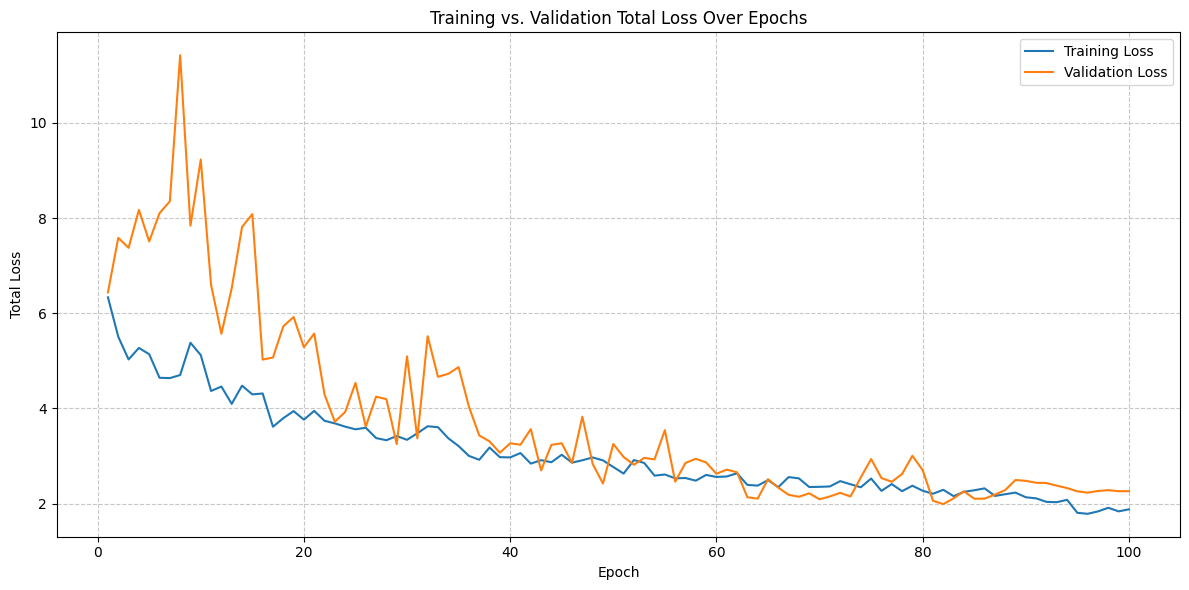

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total training and validation loss
df2['total_train_loss'] = df2['train/box_loss'] + df2['train/cls_loss'] + df2['train/dfl_loss']
df2['total_val_loss'] = df2['val/box_loss'] + df2['val/cls_loss'] + df2['val/dfl_loss']

plt.figure(figsize=(12, 6))
sns.lineplot(x='epoch', y='total_train_loss', data=df2, label='Training Loss')
sns.lineplot(x='epoch', y='total_val_loss', data=df2, label='Validation Loss')
plt.title('Training vs. Validation Total Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Precision and Recall Trends

### mAP@50 and mAP@50-95 Trends

### Learning Rate Trends

### Individual Loss Components Trends

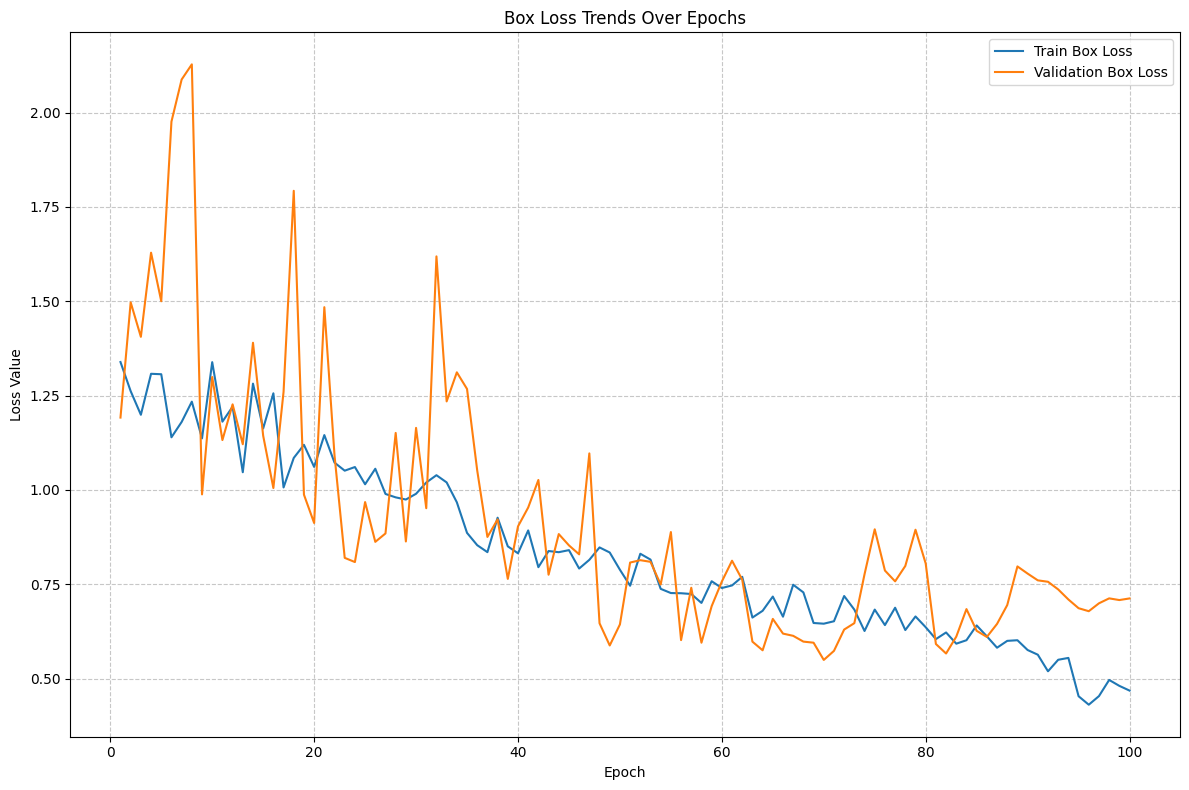

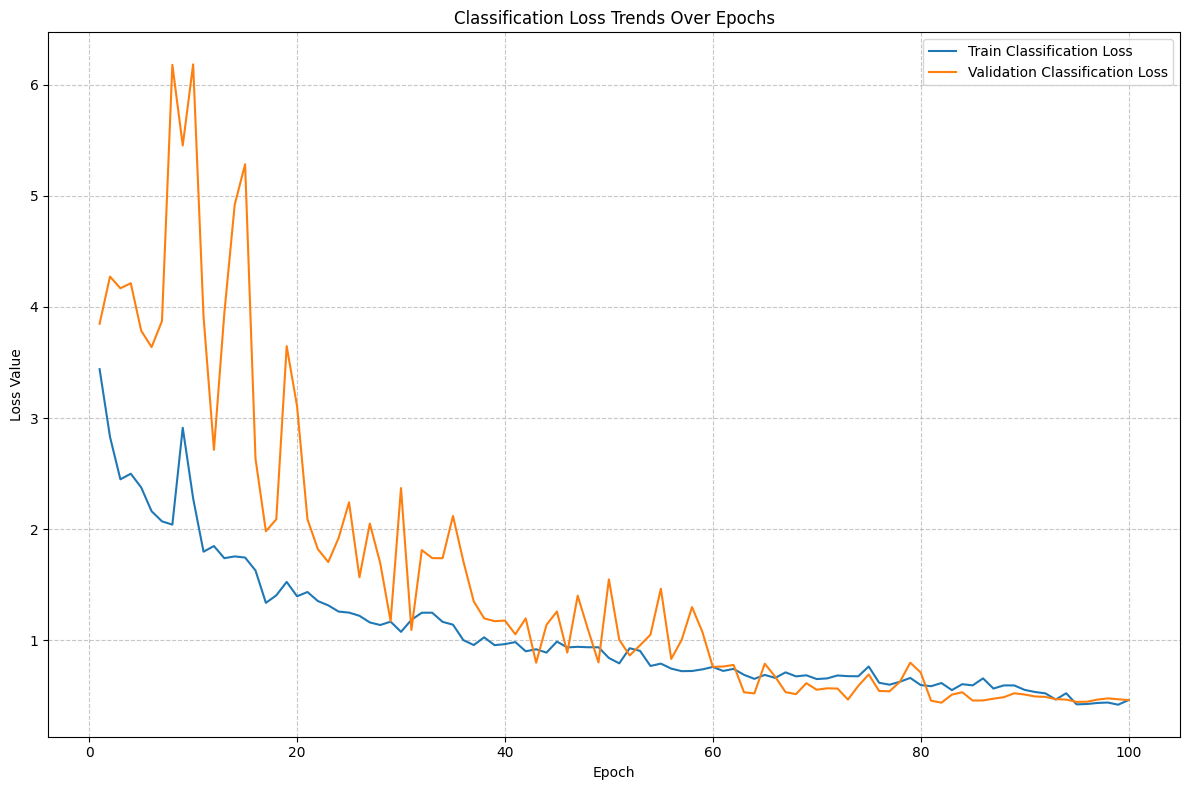

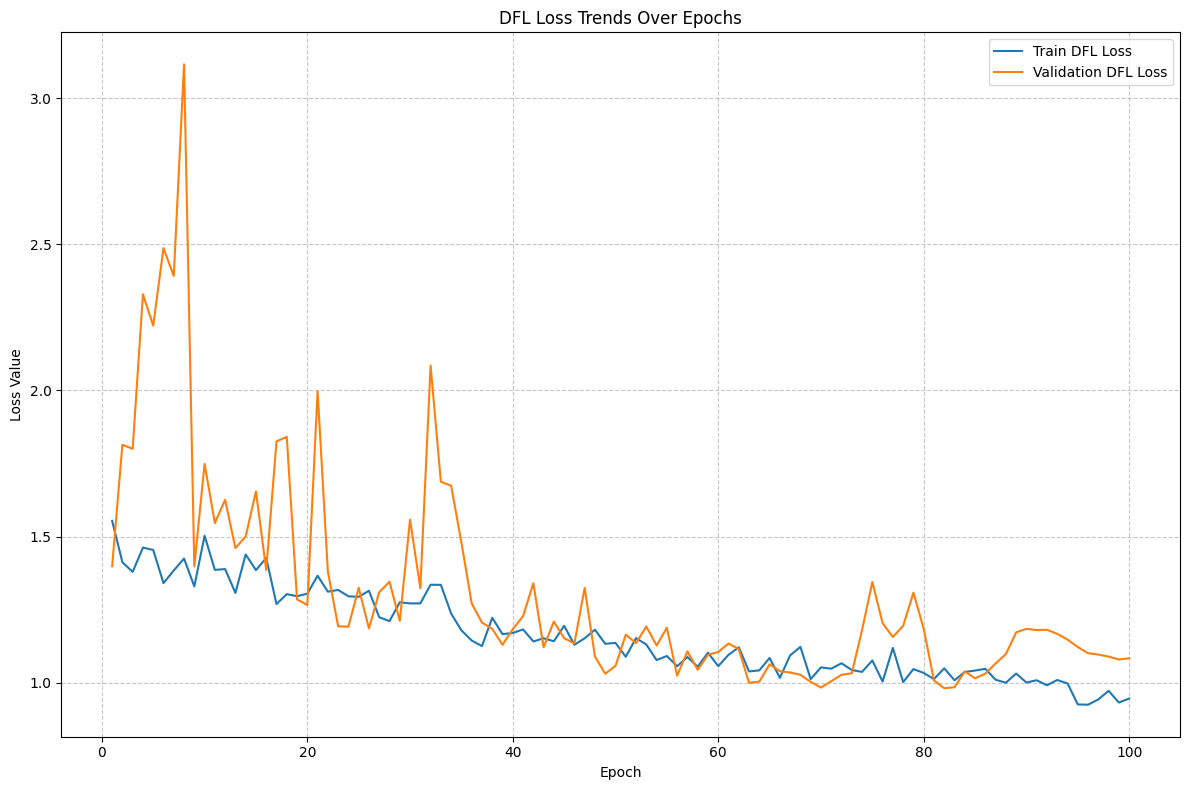

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.lineplot(x='epoch', y='train/box_loss', data=df2, label='Train Box Loss')
sns.lineplot(x='epoch', y='val/box_loss', data=df2, label='Validation Box Loss')
plt.title('Box Loss Trends Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.lineplot(x='epoch', y='train/cls_loss', data=df2, label='Train Classification Loss')
sns.lineplot(x='epoch', y='val/cls_loss', data=df2, label='Validation Classification Loss')
plt.title('Classification Loss Trends Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.lineplot(x='epoch', y='train/dfl_loss', data=df2, label='Train DFL Loss')
sns.lineplot(x='epoch', y='val/dfl_loss', data=df2, label='Validation DFL Loss')
plt.title('DFL Loss Trends Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Correlation Matrix of Loss Components

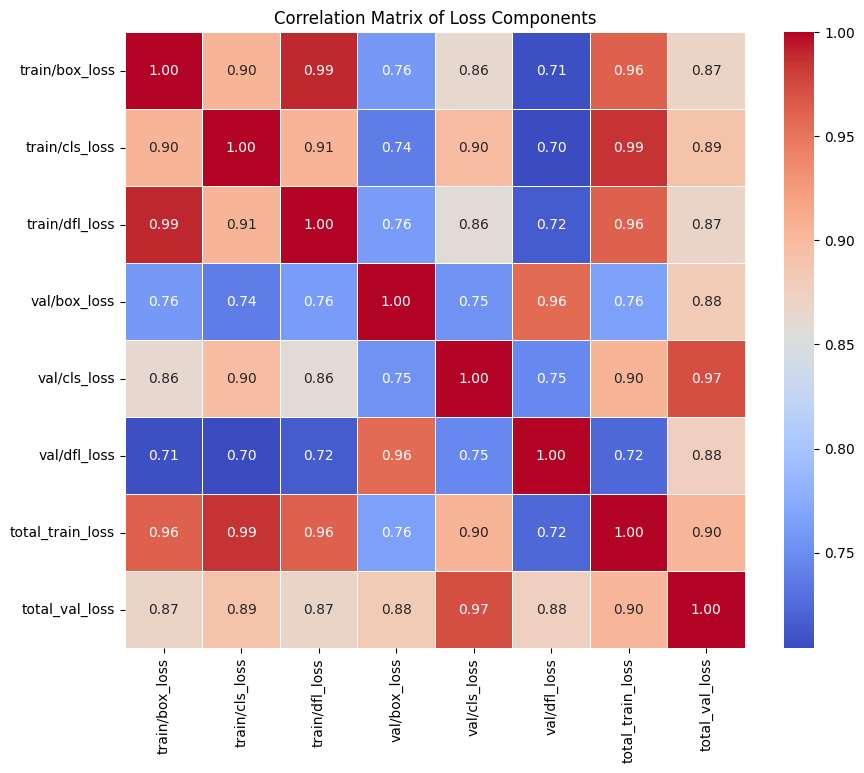

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the loss-related columns for correlation analysis
loss_columns = [
    'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
    'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
    'total_train_loss', 'total_val_loss'
]

# Calculate the correlation matrix
correlation_matrix = df2[loss_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Loss Components')
plt.show()

### Summary of Experiment 1 vs. Experiment 2

Based on the comparison table and the analysis of mAP@50-95:

```
exp1 — best (ep. 54)  exp1 — final (ep. 60)  exp2 — best (ep. 81)  exp2 — final (ep. 100)
Precision                1.0000                 0.9921               0.9819                0.9714
Recall                   0.9626                 0.9706               0.9706                0.9984
mAP@50                   0.9939                 0.9939               0.9934                0.9910
mAP@50-95                0.8812                 0.8409               0.8876                0.8412
```

The best-epoch mAP@50-95 delta (exp2 - exp1) is `+0.0064`, indicating that **more epochs helped** in this experiment.

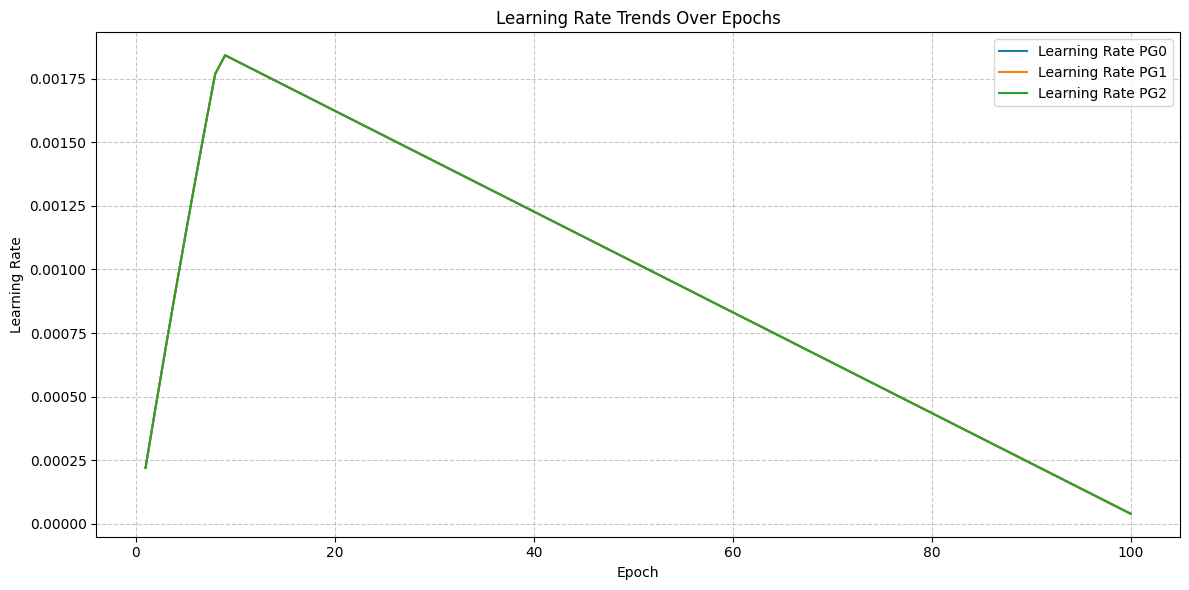

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='epoch', y='lr/pg0', data=df2, label='Learning Rate PG0')
sns.lineplot(x='epoch', y='lr/pg1', data=df2, label='Learning Rate PG1')
sns.lineplot(x='epoch', y='lr/pg2', data=df2, label='Learning Rate PG2')
plt.title('Learning Rate Trends Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

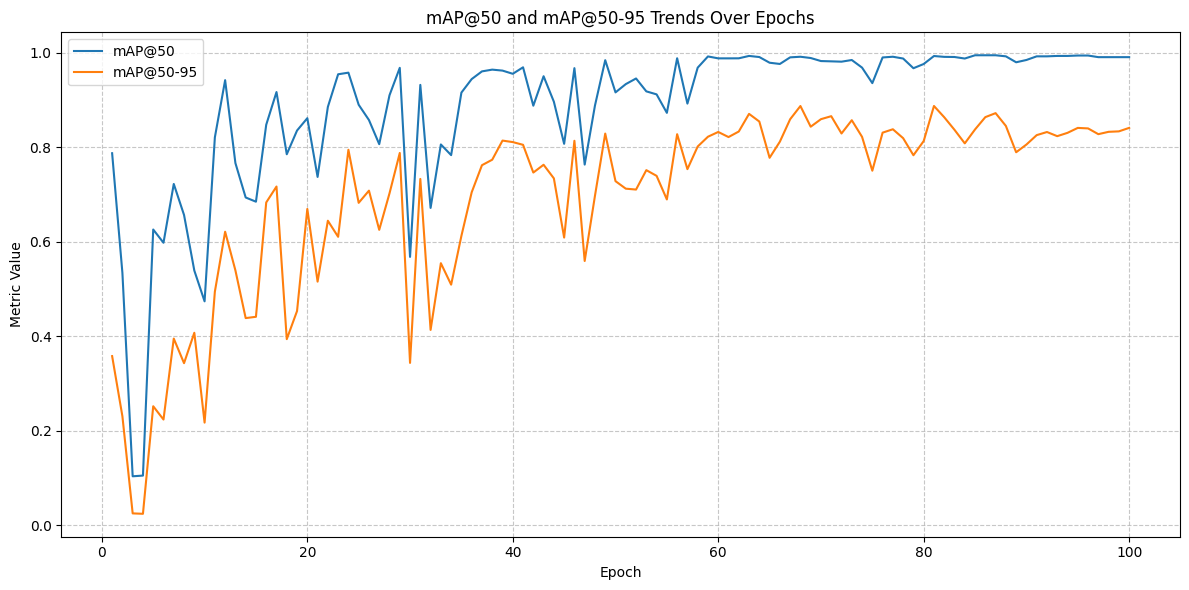

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df2, label='mAP@50')
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df2, label='mAP@50-95')
plt.title('mAP@50 and mAP@50-95 Trends Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

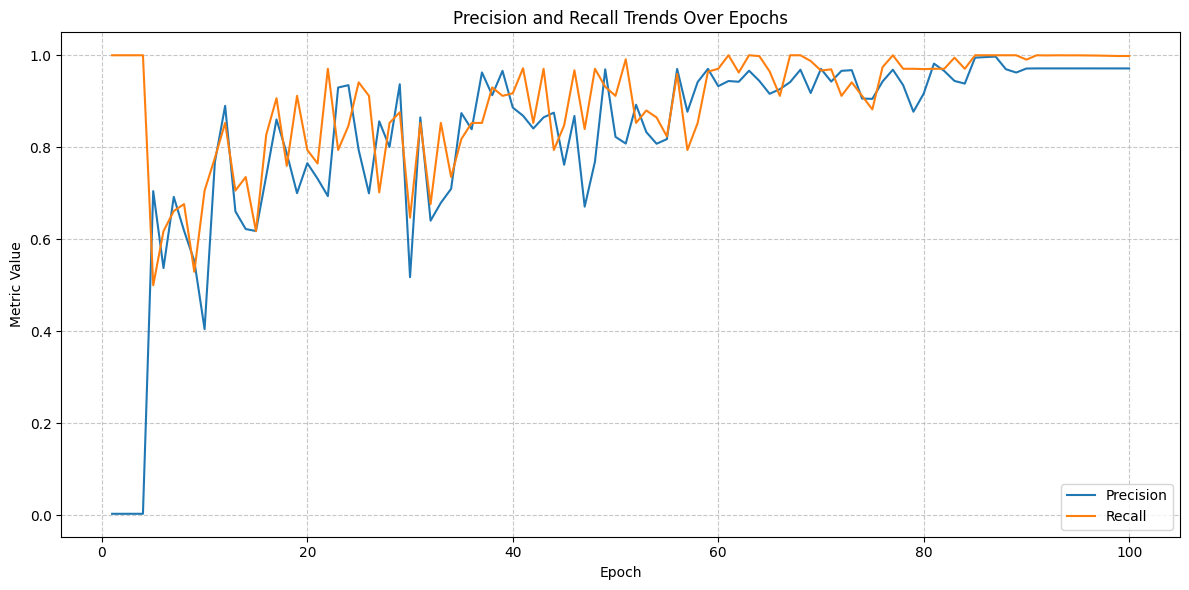

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='epoch', y='metrics/precision(B)', data=df2, label='Precision')
sns.lineplot(x='epoch', y='metrics/recall(B)', data=df2, label='Recall')
plt.title('Precision and Recall Trends Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 5️⃣ Sample Inference

---


Running inference on: tile_z19_x193909_y297359_jpg.rf.65713181c89839cb48023c6525bd4167.jpg

image 1/1 /content/My-First-Project-2/valid/images/tile_z19_x193909_y297359_jpg.rf.65713181c89839cb48023c6525bd4167.jpg: 640x640 1 heliponto, 10.8ms
Speed: 4.2ms preprocess, 10.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


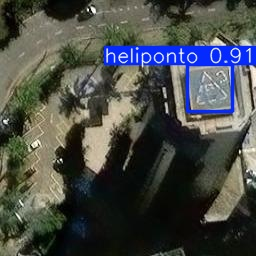

In [9]:
import os
from pathlib import Path
from IPython.display import Image, display

val_images_path = Path(dataset.location) / 'valid' / 'images'
sample_images = sorted(val_images_path.glob('*.jpg')) if val_images_path.exists() else []

if sample_images:
    sample = sample_images[0]
    print(f'Running inference on: {sample.name}')
    pred = model.predict(source=str(sample), save=True, conf=0.5)
    predict_dirs = sorted(Path('runs/detect').glob('predict*'))
    if predict_dirs:
        result_path = predict_dirs[-1] / sample.name
        if result_path.exists():
            display(Image(filename=str(result_path)))
else:
    print(f'No validation images found at {val_images_path}')


## ✅ Summary

---


In [10]:
from IPython.display import Markdown, display

summary = f"""
| Artifact | Path |
|---|---|
| Trained weights | `{save_dir}/weights/best.pt` |
| ONNX export | `{onnx_path}` |
| Metrics | `{save_dir}/results.csv` |

**Next steps:** copy `{save_dir}/results.csv` into the repo at
`artifacts/runs/runs/detect/exp2/results.csv` and share it so the README's exp1-vs-exp2 table
(currently marked *pending*) can be completed with real numbers.
"""
display(Markdown(summary))



| Artifact | Path |
|---|---|
| Trained weights | `/content/runs/detect/runs/detect/exp2/weights/best.pt` |
| ONNX export | `/content/runs/detect/runs/detect/exp2/weights/best.onnx` |
| Metrics | `/content/runs/detect/runs/detect/exp2/results.csv` |

**Next steps:** copy `/content/runs/detect/runs/detect/exp2/results.csv` into the repo at 
`artifacts/runs/runs/detect/exp2/results.csv` and share it so the README's exp1-vs-exp2 table 
(currently marked *pending*) can be completed with real numbers.


In [11]:
import shutil

shutil.make_archive('exp2_zipped', 'zip', save_dir)
print('Created exp2_zipped.zip')

try:
    from google.colab import files
    files.download('exp2_zipped.zip')
except ImportError:
    print('Not running in Colab — find exp2_zipped.zip in the current working directory.')


Created exp2_zipped.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import shutil

# Create a zip archive of the My-First-Project-2 folder
shutil.make_archive('My-First-Project-2_zipped', 'zip', 'My-First-Project-2')
print('Created My-First-Project-2_zipped.zip')

try:
    from google.colab import files
    files.download('My-First-Project-2_zipped.zip')
except ImportError:
    print('Not running in Colab — find My-First-Project-2_zipped.zip in the current working directory.')

Created My-First-Project-2_zipped.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>